# 5.0 Evaluación de los modelos

Esta fase evalúa los clusters de estudiantes con bajo INSE y responde la pregunta:

> **¿Qué caracteriza a los perfiles de resiliencia académica, es decir, estudiantes con bajo INSE que logran ubicarse en percentiles sobresalientes en Saber Pro?**

Los resultados académicos no participaron en la formación de los clusters; aquí se utilizan para interpretarlos.

## 1. Carga reproducible de resultados

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = Path.cwd() if Path('src').exists() else Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.make_dataset import default_paths, load_cluster_results
from src.features.build_features import BINARY_COLUMNS
from src.models.evaluate_model import internal_metrics, kmeans_profile, dbscan_profile

sns.set_theme(style='whitegrid')
paths = default_paths()
df = load_cluster_results(paths['cluster_data'])
summary = json.loads(paths['summary'].read_text(encoding='utf-8'))
cluster_names = {int(key): value for key, value in summary['kmeans']['cluster_names'].items()}
print(f'Resultados: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Resultados: 61,943 filas x 52 columnas


## 2. Cobertura y métricas internas

In [2]:
pca_columns = [column for column in df if column.startswith('pca_') and not column.startswith('pca_plot_')]
dbscan_pca_columns = [column for column in df if column.startswith('dbscan_pca_')]
assert df['cluster_kmeans'].notna().all()
assert df['cluster_dbscan'].notna().sum() == 30_000

kmeans_metrics = internal_metrics(
    df[pca_columns].to_numpy(dtype='float32'),
    df['cluster_kmeans'].to_numpy(),
)
dbscan_sample = df[df['cluster_dbscan'].notna()].copy()
dbscan_grouped = dbscan_sample[dbscan_sample['cluster_dbscan'] != -1]
dbscan_metrics = internal_metrics(
    dbscan_grouped[dbscan_pca_columns].to_numpy(dtype='float32'),
    dbscan_grouped['cluster_dbscan'].astype(int).to_numpy(),
)
metrics = pd.DataFrame([kmeans_metrics, dbscan_metrics], index=['K-Means', 'DBSCAN'])
display(metrics.round(3))

,silhouette,davies_bouldin,calinski_harabasz
K-Means,0.167,1.719,11734.545
DBSCAN,0.423,0.709,9593.252


K-Means obtiene un Silhouette cercano a **0,167** y Davies-Bouldin cercano a **1,719**. Esto indica que los perfiles comparten características y no tienen fronteras rígidas. DBSCAN obtiene un Silhouette cercano a **0,423** y Davies-Bouldin cercano a **0,709** sobre los puntos agrupados de su muestra.

## 3. Perfiles de K-Means

,cluster_kmeans,estudiantes,puntaje_promedio,percentil_promedio,inse_promedio,bienes_promedio,resilientes,tasa_resiliencia,porcentaje_poblacion,participacion_resilientes,indice_concentracion,nombre
0,0,21541,133.95,35.95,35.73,2.83,508,2.36,34.78,23.01,0.66,Mayor vulnerabilidad observada
1,1,19417,138.39,40.96,38.88,3.22,752,3.87,31.35,34.06,1.09,Mayor disponibilidad material
2,2,5272,137.65,40.24,37.56,2.73,167,3.17,8.51,7.56,0.89,Preparación académica reportada
3,3,15713,140.16,43.37,38.93,2.70,781,4.97,25.37,35.37,1.39,Mayor capital educativo familiar


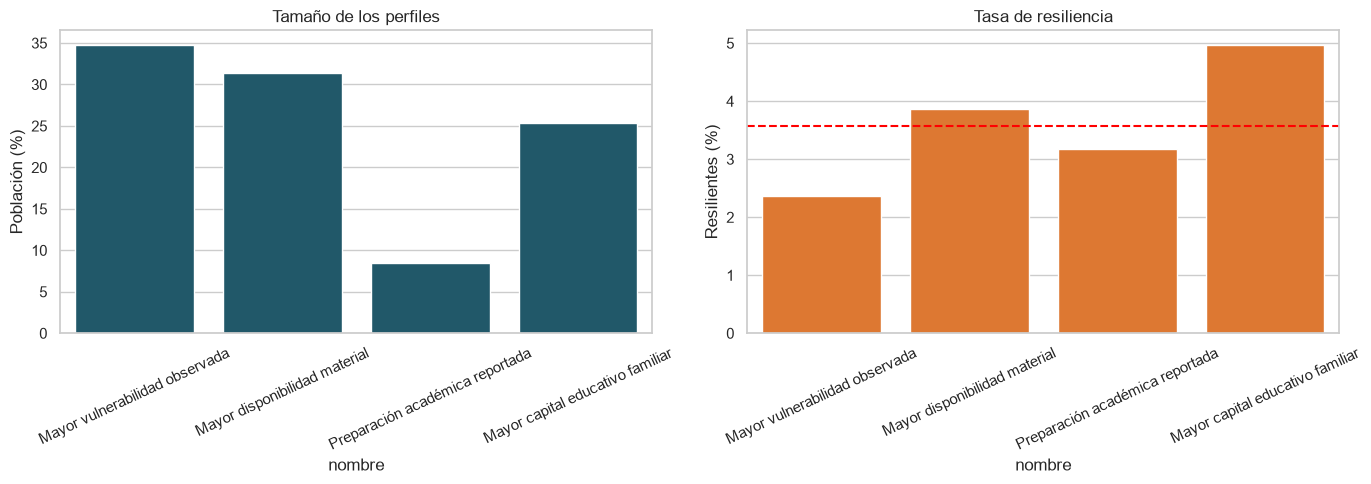

In [3]:
profile = kmeans_profile(df).reset_index()
profile['nombre'] = profile['cluster_kmeans'].astype(int).map(cluster_names)
display(profile.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=profile, x='nombre', y='porcentaje_poblacion', color='#155e75', ax=axes[0])
axes[0].set_title('Tamaño de los perfiles')
axes[0].set_ylabel('Población (%)')
axes[0].tick_params(axis='x', rotation=25)
sns.barplot(data=profile, x='nombre', y='tasa_resiliencia', color='#f97316', ax=axes[1])
axes[1].axhline(df['resiliencia_flag'].mean() * 100, color='red', linestyle='--')
axes[1].set_title('Tasa de resiliencia')
axes[1].set_ylabel('Resilientes (%)')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

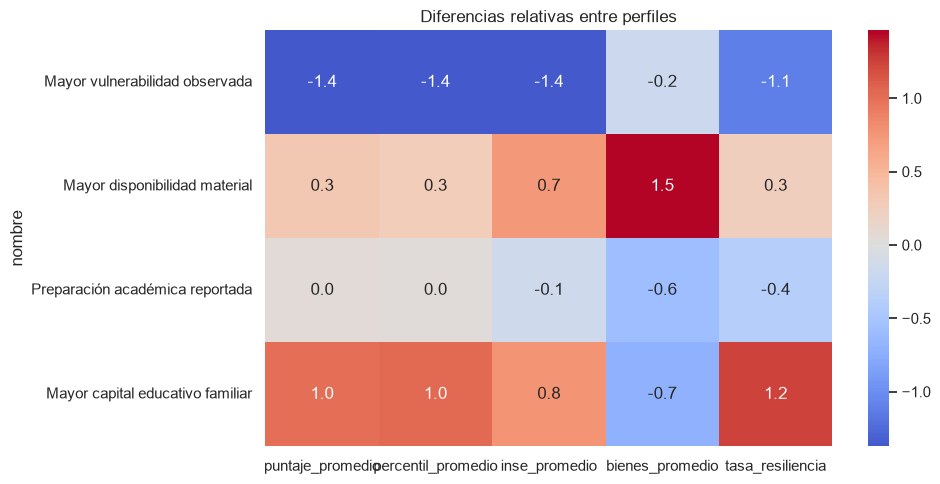

In [4]:
heatmap_columns = ['puntaje_promedio', 'percentil_promedio', 'inse_promedio',
                   'bienes_promedio', 'tasa_resiliencia']
heatmap = profile.set_index('nombre')[heatmap_columns]
heatmap = (heatmap - heatmap.mean()) / heatmap.std()
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap, annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title('Diferencias relativas entre perfiles')
plt.tight_layout()
plt.show()

El perfil **Mayor capital educativo familiar** presenta el puntaje, percentil y tasa de resiliencia más altos. Su cantidad promedio de bienes es menor que la del perfil **Mayor disponibilidad material**, lo que indica que los recursos materiales observados no explican por sí solos la concentración de resiliencia.

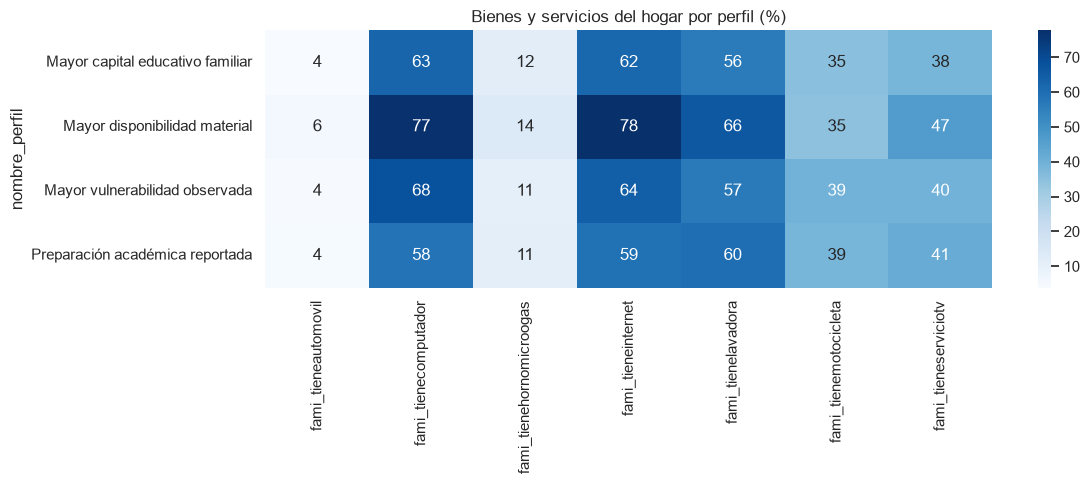

In [5]:
goods = df.assign(nombre_perfil=df['cluster_kmeans'].astype(int).map(cluster_names))
goods = goods.groupby('nombre_perfil')[BINARY_COLUMNS].agg(lambda column: column.eq('Si').mean() * 100)
plt.figure(figsize=(12, 5))
sns.heatmap(goods, annot=True, fmt='.0f', cmap='Blues')
plt.title('Bienes y servicios del hogar por perfil (%)')
plt.tight_layout()
plt.show()

Los cuatro perfiles se interpretan así:

- **Mayor vulnerabilidad observada:** predomina estrato 1 y educación primaria incompleta de los padres; tiene la menor resiliencia.
- **Mayor disponibilidad material:** concentra estratos 2 y 3, computador, internet y otros bienes.
- **Preparación académica reportada:** reúne estudiantes con información disponible sobre refuerzos, cursos y simulacros. La diferencia también refleja el diligenciamiento del bloque.
- **Mayor capital educativo familiar:** combina estratos bajos y pocos bienes con niveles educativos parentales relativamente mayores.

## 4. Resiliencia académica

In [6]:
resilient_count = int(df['resiliencia_flag'].sum())
resilience_rate = df['resiliencia_flag'].mean() * 100
print(f'Estudiantes resilientes: {resilient_count:,}')
print(f'Tasa de resiliencia: {resilience_rate:.2f}%')
display(profile[['nombre', 'estudiantes', 'resilientes', 'tasa_resiliencia',
                 'participacion_resilientes', 'indice_concentracion']].round(2))

df['grupo_resiliencia'] = np.where(
    df['resiliencia_flag'], 'Resiliente', 'Bajo INSE no sobresaliente'
)
display(df.groupby('grupo_resiliencia')[
    ['punt_global', 'percentil_global', 'estu_inse_individual', 'indice_bienes_hogar']
].agg(['mean', 'median']).round(2))

Estudiantes resilientes: 2,208
Tasa de resiliencia: 3.56%


,nombre,estudiantes,resilientes,tasa_resiliencia,participacion_resilientes,indice_concentracion
0,Mayor vulnerabilidad observada,21541,508,2.36,23.01,0.66
1,Mayor disponibilidad material,19417,752,3.87,34.06,1.09
2,Preparación académica reportada,5272,167,3.17,7.56,0.89
3,Mayor capital educativo familiar,15713,781,4.97,35.37,1.39


punt_global        percentil_global         \
                                  mean median             mean median   
grupo_resiliencia                                                       
Bajo INSE no sobresaliente      135.40  136.0            37.76   35.0   
Resiliente                      186.88  184.0            94.03   94.0   

                           estu_inse_individual        indice_bienes_hogar  \
                                           mean median                mean   
grupo_resiliencia                                                            
Bajo INSE no sobresaliente                37.65  38.60                2.91   
Resiliente                                38.68  39.56                2.97   

                                   
                           median  
grupo_resiliencia                  
Bajo INSE no sobresaliente    3.0  
Resiliente                    3.0

In [7]:
def compare_category(column, top=8):
    table = pd.crosstab(df[column], df['grupo_resiliencia'], normalize='columns') * 100
    table['diferencia_pp'] = table['Resiliente'] - table['Bajo INSE no sobresaliente']
    return table.sort_values('diferencia_pp', ascending=False).head(top).round(2)

for column in ['fami_educacionmadre', 'fami_educacionpadre',
               'estu_metodo_prgm', 'inst_caracter_academico', 'inst_origen']:
    print(f'Comparación para: {column}')
    display(compare_category(column))

Comparación para: fami_educacionmadre


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
fami_educacionmadre,,,
Secundaria (Bachillerato) completa,22.49,29.80,7.31
Secundaria (Bachillerato) incompleta,12.68,15.81,3.12
Técnica o tecnológica completa,6.74,9.38,2.63
Educación profesional completa,2.45,4.94,2.49
Educación profesional incompleta,0.61,1.63,1.02
No sabe,0.45,0.95,0.50
Postgrado,0.42,0.77,0.35
Técnica o tecnológica incompleta,2.21,2.13,-0.08


Comparación para: fami_educacionpadre


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
fami_educacionpadre,,,
Secundaria (Bachillerato) completa,18.34,22.37,4.04
Secundaria (Bachillerato) incompleta,11.15,13.99,2.85
Educación profesional completa,2.02,4.62,2.60
Técnica o tecnológica completa,4.23,6.02,1.79
No sabe,1.71,3.26,1.55
No Aplica,1.48,2.26,0.78
Educación profesional incompleta,0.57,1.22,0.66
Postgrado,0.30,0.82,0.52


Comparación para: estu_metodo_prgm


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
estu_metodo_prgm,,,
PRESENCIAL,64.94,93.93,29.00
SEMI-PRESENCIAL,0.01,0.00,-0.01
DISTANCIA VITUAL,13.05,2.99,-10.06
DISTANCIA,22.01,3.08,-18.93


Comparación para: inst_caracter_academico


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
inst_caracter_academico,,,
UNIVERSIDAD,57.36,89.99,32.63
TÉCNICA PROFESIONAL,3.23,0.36,-2.87
INSTITUCIÓN TECNOLÓGICA,5.14,0.59,-4.55
INSTITUCIÓN UNIVERSITARIA,34.27,9.06,-25.22


Comparación para: inst_origen


grupo_resiliencia,Bajo INSE no sobresaliente,Resiliente,diferencia_pp
inst_origen,,,
OFICIAL DEPARTAMENTAL,26.14,37.09,10.95
OFICIAL NACIONAL,28.24,31.20,2.97
OFICIAL MUNICIPAL,3.09,4.35,1.26
REGIMEN ESPECIAL,0.04,0.00,-0.04
NO OFICIAL - FUNDACIÓN,19.99,13.99,-6.00
NO OFICIAL - CORPORACIÓN,22.50,13.36,-9.14


Se identifican **2.208 estudiantes resilientes**, equivalentes al **3,56%** de la población con bajo INSE. El perfil de mayor capital educativo familiar alcanza una tasa cercana al **4,97%**, aproximadamente 1,4 veces el promedio, y reúne alrededor del 35% de los casos. La cantidad de bienes es semejante entre resilientes y no resilientes, mientras la educación parental media y superior tiene mayor presencia entre los resilientes.

## 5. Resultados de DBSCAN

In [8]:
density_profile = dbscan_profile(df)
display(density_profile.round(2))
noise_rate = (dbscan_sample['cluster_dbscan'] == -1).mean() * 100
largest_cluster = dbscan_grouped['cluster_dbscan'].value_counts(normalize=True).max() * 100
print(f'Clusters: {dbscan_grouped["cluster_dbscan"].nunique()}')
print(f'Ruido: {noise_rate:.2f}%')
print(f'Cluster dominante: {largest_cluster:.2f}% de los puntos agrupados')

,estudiantes,resilientes,tasa_resiliencia,puntaje_promedio,inse_promedio,bienes_promedio
cluster_dbscan,,,,,,
-1.0,2088,93,4.45,138.73,38.14,2.72
0.0,9955,406,4.08,139.22,38.98,3.07
1.0,14803,437,2.95,135.45,36.64,2.80
2.0,1796,75,4.18,138.66,39.56,3.28
3.0,96,11,11.46,141.98,38.95,2.52
4.0,1161,35,3.01,137.43,36.78,2.71
5.0,101,2,1.98,134.74,38.28,3.27


Clusters: 6
Ruido: 6.96%
Cluster dominante: 53.03% de los puntos agrupados


DBSCAN encuentra seis grupos y marca el 6,96% de su muestra como ruido. El cluster 3 muestra una tasa elevada de resiliencia, pero contiene solo 96 estudiantes, por lo que no es suficiente para generalizar. Ser ruido significa poseer un contexto poco común, no ser necesariamente resiliente.

## 6. Conclusiones

1. La resiliencia corresponde al 3,56% de los estudiantes con bajo INSE.
2. El perfil con mayor capital educativo familiar concentra la tasa más alta de resiliencia, 4,97%.
3. La educación de los padres diferencia mejor ese perfil que la cantidad de bienes del hogar.
4. El perfil de mayor vulnerabilidad observada presenta la tasa más baja de resiliencia.
5. El perfil de preparación reportada está influido por la disponibilidad del bloque de preguntas y debe interpretarse con precaución.
6. K-Means ofrece perfiles amplios para toda la población; DBSCAN complementa el análisis sobre una muestra.
7. Los perfiles se superponen y las asociaciones encontradas no permiten establecer causalidad.